<a href="https://colab.research.google.com/github/00ayeshazahra/WWTP-Predictive-Maintainance/blob/main/Pump1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
import pandas as pd
import glob
import os

TIME_COL = "Time (yyyy/mm/dd hh:mm:ss)"

def load_sensor_csvs(folder_path):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    df_list = []

    for file in csv_files:
        # Updated pd.read_csv with correct parameters
        df = pd.read_csv(file, sep=';', decimal=',', header=8, usecols=[0, 1], parse_dates=[0])

        # Clean column names
        df.columns = (
            df.columns
            .str.replace(",+", "", regex=True)
            .str.strip()
        )

        # Convert time (this might be redundant if parse_dates=[0] works perfectly, but acts as safeguard)
        df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")

        df_list.append(df)

    combined = pd.concat(df_list, ignore_index=True)

    # Remove invalid timestamps
    combined = combined.dropna(subset=[TIME_COL])

    # Sort chronologically (CRITICAL)
    combined = combined.sort_values(TIME_COL).reset_index(drop=True)

    # Merge duplicate sensor columns (This step might not be needed with usecols=[0,1], but keeping for robustness)
    combined = combined.groupby(level=0, axis=1).first()

    return combined

In [110]:
current_df = load_sensor_csvs(
    "/content/drive/MyDrive/SCADA/Pump1/Current"
)

temperature_df = load_sensor_csvs(
    "/content/drive/MyDrive/SCADA/Pump1/main bearing temperature"
)

vibX_df = load_sensor_csvs(
    "/content/drive/MyDrive/SCADA/Pump1/vibration x"
)

vibY_df = load_sensor_csvs(
    "/content/drive/MyDrive/SCADA/Pump1/vibration y"
)

/tmp/ipykernel_846/2202586311.py:36: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  combined = combined.groupby(level=0, axis=1).first()
/tmp/ipykernel_846/2202586311.py:36: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  combined = combined.groupby(level=0, axis=1).first()
/tmp/ipykernel_846/2202586311.py:36: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  combined = combined.groupby(level=0, axis=1).first()
/tmp/ipykernel_846/2202586311.py:36: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  combined = combined.groupby(level=0, axis=1).first()


In [112]:
print("Current DF columns:")
print(current_df.columns.tolist())

print("\nTemperature DF columns:")
print(temperature_df.columns.tolist())

print("\nVibration X DF columns:")
print(vibX_df.columns.tolist())

print("\nVibration Y DF columns:")
print(vibY_df.columns.tolist())

Current DF columns:
['3531.766-2386020:Pump current (A)', 'Time (yyyy/mm/dd hh:mm:ss)']

Temperature DF columns:
['3531.766-2386020:Main bearing (°C)', 'Time (yyyy/mm/dd hh:mm:ss)']

Vibration X DF columns:
['3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s)', 'Time (yyyy/mm/dd hh:mm:ss)']

Vibration Y DF columns:
['3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s)', 'Time (yyyy/mm/dd hh:mm:ss)']


In [ ]:
combined_df = pd.merge(current_df, temperature_df, on=TIME_COL, how="outer")
combined_df = pd.merge(combined_df, vibX_df, on=TIME_COL, how="outer")
combined_df = pd.merge(combined_df, vibY_df, on=TIME_COL, how="outer")

combined_df = combined_df.sort_values(TIME_COL).reset_index(drop=True)

In [ ]:
sensor_cols = combined_df.columns.drop(TIME_COL)

combined_df[sensor_cols] = combined_df[sensor_cols].apply(
    pd.to_numeric, errors="coerce"
)

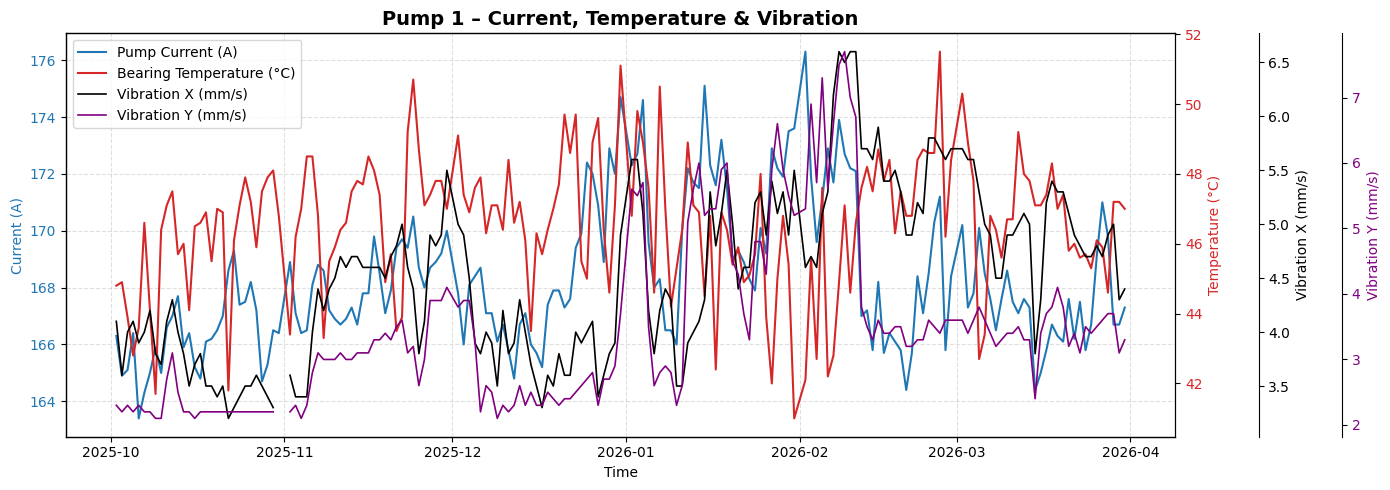

In [118]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax1 = plt.subplots(figsize=(14, 5))

# --- Pump Current ---
line1, = ax1.plot(
    combined_df[TIME_COL],
    combined_df["3531.766-2386020:Pump current (A)"],
    color="tab:blue",
    linewidth=1.5,
    label="Pump Current (A)"
)
ax1.set_ylabel("Current (A)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, linestyle="--", alpha=0.4)

# --- Bearing Temperature ---
ax2 = ax1.twinx()
line2, = ax2.plot(
    combined_df[TIME_COL],
    combined_df["3531.766-2386020:Main bearing (°C)"],
    color="tab:red",
    linewidth=1.5,
    label="Bearing Temperature (°C)"
)
ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# --- Vibration X ---
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("outward", 60))
line3, = ax3.plot(
    combined_df[TIME_COL],
    combined_df["3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s)"],
    color="black",
    linewidth=1.2,
    label="Vibration X (mm/s)"
)
ax3.set_ylabel("Vibration X (mm/s)", color="black")
ax3.tick_params(axis="y", labelcolor="black")

# --- Vibration Y ---
ax4 = ax1.twinx()
ax4.spines["right"].set_position(("outward", 120))
line4, = ax4.plot(
    combined_df[TIME_COL],
    combined_df["3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s)"],
    color="purple",
    linewidth=1.2,
    label="Vibration Y (mm/s)"
)
ax4.set_ylabel("Vibration Y (mm/s)", color="purple")
ax4.tick_params(axis="y", labelcolor="purple")

# --- X‑axis formatting ---
ax1.set_xlabel("Time")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

# --- Title ---
plt.title("Pump 1 – Current, Temperature & Vibration", fontsize=14, weight="bold")

# --- Combined legend ---
lines = [line1, line2, line3, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

In [119]:
cols = [
    "3531.766-2386020:Pump current (A)",
    "3531.766-2386020:Main bearing (°C)",
    "3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s)",
    "3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s)"
]

corr_df = combined_df[cols]

In [121]:
correlation_table = corr_df.corr(method="pearson")
correlation_table

correlation_table.round(3)

,3531.766-2386020:Pump current (A),3531.766-2386020:Main bearing (°C),3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s),3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s)
3531.766-2386020:Pump current (A),1.000,-0.073,0.368,0.702
3531.766-2386020:Main bearing (°C),-0.073,1.000,0.066,-0.128
3531.766-2386020:Vibration X (radial perpendicular to cable entry) (mm/s),0.368,0.066,1.000,0.713
3531.766-2386020:Vibration Y (radial towards cable entry) (mm/s),0.702,-0.128,0.713,1.000


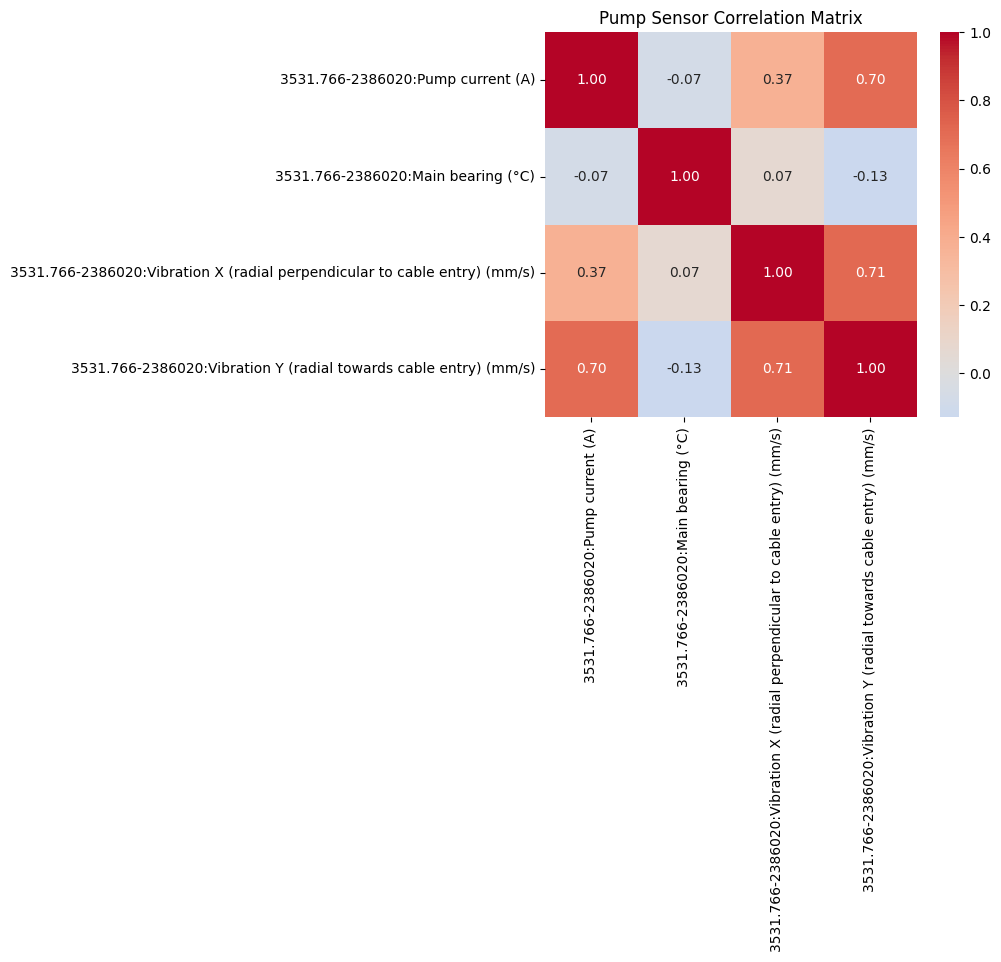

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(
    correlation_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Pump Sensor Correlation Matrix")
plt.show()